# **Machine Learning with PyTorch**

PyTorch is an open source framework for AI research and commercial production in machine learning. It is used to build, train, and optimize deep learning neural networks for applications such as image recognition, natural language processing, and speech recognition. It provides computation support for CPU, GPU, parallel and distributed training on multiple GPUs and multiple nodes. PyTorch is also flexible and easily extensible, with specific libraries and tools available for many different domains. More information at https://pytorch.org

MNIST dataset at https://archive.ics.uci.edu/dataset/683/mnist+database+of+handwritten+digits

---


# Objectives

This notebook will be able to:

 - Install necessary PyTorch libraries;
 - Use PyTorch to build, train and evaluate neural networks.
 - Save the trained model parameters and use them later for inferencing.


---


# Setup

### Installing libraries

The following libraries are installed in Jupyter environment (e.g. VS Code, Sagemaker, Google Collab, or Ananconda), you will need to install these libraries.

*   [`torch`](https://pytorch.org/docs/stable/library.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkGuidedProjectsIBMDeveloperGPXX0W98EN3615-2023-01-01)
*   [`TorchVision`](https://pytorch.org/vision/stable/index.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkGuidedProjectsIBMDeveloperGPXX0W98EN3615-2023-01-01)


In [1]:
%pip install torch torchvision matplotlib ipython-autotime

%load_ext autotime

Note: you may need to restart the kernel to use updated packages.
time: 144 μs (started: 2025-04-10 16:13:41 -07:00)


### Importing libraries

I recommend import all required libraries in one place (here):_


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

import numpy as np
import matplotlib.pyplot as plt

time: 1.49 s (started: 2025-04-10 16:13:41 -07:00)


# How does this code work?
 
This notebook uses [MNIST dataset of Handwritten Digits](https://archive.ics.uci.edu/dataset/683/mnist+database+of+handwritten+digits). The dataset has over 60,000 images of hand written digits. The data will be partitioned between training the AI model and testing the AI model after training.

The main steps in this project include:
 1. Download the MNIST dataset and create a DataLoader for the dataset.
 2. Define an AI model to recognize a hand written digit.
 3. Train the defined AI model using training data from the MNIST dataset.
 4. Test the trained AI model using testing data from the MNIST dataset.
 5. Evaluate


# Download dataset and dreate Data Loader

The images are 28x28 pixel images of digits 0 through 9.


In [3]:
# Download training data from MNIST datasets.
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

batch_size = 64

# Create data loaders to iterate over data
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

print("Training data size:", len(train_dataloader) * batch_size)
print("Test data size:", len(test_dataloader) * batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Training data size: 60032
Test data size: 10048
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
time: 47.2 ms (started: 2025-04-10 16:13:42 -07:00)


In [4]:
training_data.targets.numpy(), training_data.targets.numpy().shape, training_data.targets.numpy().dtype

(array([5, 0, 4, ..., 5, 6, 8]), (60000,), dtype('int64'))

time: 1.52 ms (started: 2025-04-10 16:13:42 -07:00)


In [5]:
#print unique labels from training data
unique_labels = np.unique(training_data.targets.numpy(), return_counts=True)
unique_labels

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

time: 1.4 ms (started: 2025-04-10 16:13:42 -07:00)


### Display few images using matplotlib

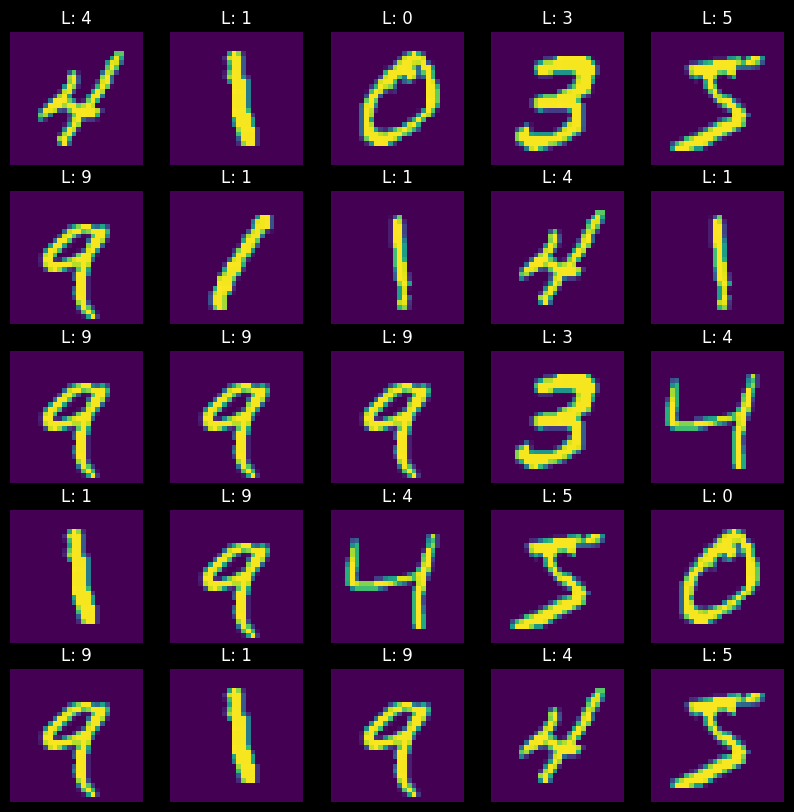

time: 346 ms (started: 2025-04-10 16:13:42 -07:00)


In [6]:
def display_few_images(sample_images, sample_labels):
    plt.figure(figsize=(10, 10))
    for i in range(25):
        idx = np.random.randint(0, len(sample_images))
        img = sample_images[idx]
        label = sample_labels[idx]
        plt.subplot(5, 5, i+1)
        plt.axis('off')
        plt.title(f"L: {label}")
        plt.imshow(img)
    plt.show()

display_few_images(training_data.data.numpy()[:10], training_data.targets.numpy()[:10])

# Define Model

I 1st determine the best device for performing training with cpu as the default device and then define the AI model as a neural network with 3 layers: an input layer, a hidden layer, and an output layer. Between the layers, we use a ReLU activation function.

Since the input images are 1x28x28 tensors, I need to flatten the input tensors into a 784 element tensor using the Flatten module before passing the input into our neural network.


In [7]:
# Get device for training.
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() # Apple Silicon GPU
    else "cpu"
)
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, image_tensor):
        image_tensor = self.flatten(image_tensor)
        logits = self.linear_relu_stack(image_tensor)
        return logits

input_size = 28*28
hidden_size = 512
num_classes = 10

model = NeuralNetwork(input_size, hidden_size, num_classes).to(device)
print(model)

Using mps device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)
time: 29.7 ms (started: 2025-04-10 16:13:43 -07:00)


# Training loop

I implement a training function to use with the train_dataloader to train our model. Each iteration over the dataloader returns a batch_size image data tensor along with the expected output. After moving the tensors to the device, calling the forward pass of the model, compute the prediction error using the expected output and then call the backwards pass to compute the gradients and apply them to the model parameters.


In [8]:
# Define our learning rate, loss function and optimizer
learning_rate = 1e-3 # 0.001
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Let's define our training function 
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()

    for batch_num, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Forward pass to compute prediction
        pred = model(X)
        # Compute prediction error using loss function
        loss = loss_fn(pred, y)

        # Backward pass
        optimizer.zero_grad() # zero any previous gradient calculations
        loss.backward() # calculate gradient
        optimizer.step() # update model parameters
        
        if batch_num > 0 and batch_num % 100 == 0:
            loss, current = loss.item(), batch_num * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

time: 1.01 ms (started: 2025-04-10 16:13:43 -07:00)


# Test Loop

The test methods evaluates the model's predictive performance using the test_dataloader. During testing, not require the gradient computation, so set the model in evaluate mode.


In [9]:
# Our test function
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        test_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

time: 391 μs (started: 2025-04-10 16:13:43 -07:00)


# Train the Model

Now, defined methods to train our model and test the trained model's predictive behavior, lets train the model for 10 epochs over the dataset.


In [10]:
# Let's run training
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 0.273363  [ 6400/60000]
loss: 0.197486  [12800/60000]
loss: 0.266008  [19200/60000]
loss: 0.128867  [25600/60000]
loss: 0.328076  [32000/60000]
loss: 0.135155  [38400/60000]
loss: 0.270187  [44800/60000]
loss: 0.328866  [51200/60000]
loss: 0.159806  [57600/60000]
Test Error: 
 Accuracy: 95.8%, Avg loss: 0.135002 

Epoch 2
-------------------------------
loss: 0.096334  [ 6400/60000]
loss: 0.089504  [12800/60000]
loss: 0.125397  [19200/60000]
loss: 0.032346  [25600/60000]
loss: 0.107028  [32000/60000]
loss: 0.058959  [38400/60000]
loss: 0.140157  [44800/60000]
loss: 0.120368  [51200/60000]
loss: 0.144620  [57600/60000]
Test Error: 
 Accuracy: 96.4%, Avg loss: 0.123309 

Epoch 3
-------------------------------
loss: 0.082541  [ 6400/60000]
loss: 0.047609  [12800/60000]
loss: 0.110141  [19200/60000]
loss: 0.011306  [25600/60000]
loss: 0.115133  [32000/60000]
loss: 0.034552  [38400/60000]
loss: 0.069220  [44800/60000]
loss: 0.107810  [51200/600

# Save the model

Once trained model, save the model parameters for future use in inferences. Save the state_dict of the model which contains the trained parameters.

In [11]:
# Save our model parameters
torch.save(model.state_dict(), "ml_with_pytorch_model.pth")
print("Saved PyTorch Model State to ml_with_pytorch_model.pth")

Saved PyTorch Model State to ml_with_pytorch_model.pth
time: 6.67 ms (started: 2025-04-10 16:14:20 -07:00)


 # Test the model with test_data
Create a new instance of the model and load the previously saved parameters into the new instance of the model. Finally I can inference using the new instance of the model.


In [12]:

# Load the saved model parameters into a new instance of the model
model = NeuralNetwork(input_size, hidden_size, num_classes).to(device)
model.load_state_dict(torch.load("ml_with_pytorch_model.pth"))

# Inference using the new model instance
model.eval()
for i in range(10):
    x, y = test_data[i][0], test_data[i][1]

    x = x.to(device)
    pred = model(x)
    predicted, actual = pred[0].argmax(0).item(), y
    print(f'Predicted: "{predicted}", Actual: "{actual}"')


Predicted: "7", Actual: "7"
Predicted: "2", Actual: "2"
Predicted: "1", Actual: "1"
Predicted: "0", Actual: "0"
Predicted: "4", Actual: "4"
Predicted: "1", Actual: "1"
Predicted: "4", Actual: "4"
Predicted: "9", Actual: "9"
Predicted: "5", Actual: "5"
Predicted: "9", Actual: "9"
time: 39.6 ms (started: 2025-04-10 16:14:20 -07:00)


# Test the model with real hand written image numbers

My handwritten images uploaded to the folder 'handwritten-images'

 File names: ['2.png', '3.png', '1.png']
Image tensor shape: torch.Size([1, 1, 28, 28])
predicted Image value: "5 and file name: 2.png"


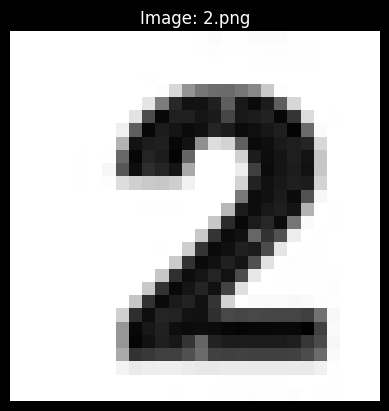


Image tensor shape: torch.Size([1, 1, 28, 28])
predicted Image value: "7 and file name: 3.png"


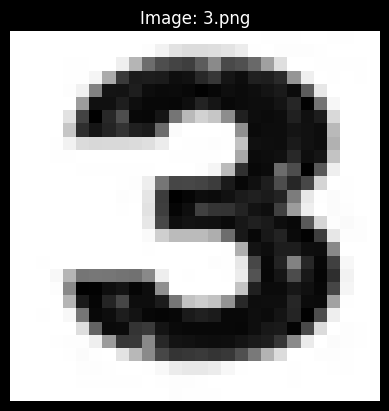


Image tensor shape: torch.Size([1, 1, 28, 28])
predicted Image value: "5 and file name: 1.png"


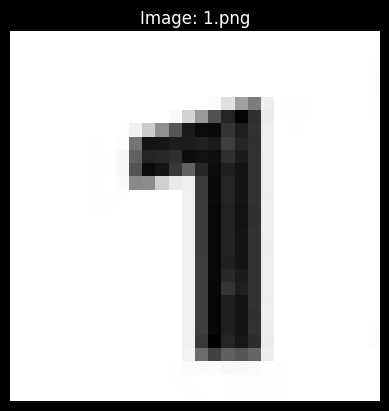


time: 176 ms (started: 2025-04-10 16:24:16 -07:00)


In [16]:
import os
from PIL import Image

# List files in the current directory
files = os.listdir('./handwritten-images')
print(f" File names: {files}")
# Iterate through the files and display images
for file in files:
    image_path = os.path.join('./handwritten-images', file)
    test_image = Image.open(image_path).convert('L')  # Convert to grayscale
    test_image = test_image.resize((28, 28))  # Resize to match MNIST dimensions

    # Load the saved model parameters into a new instance of the model
    model = NeuralNetwork(input_size, hidden_size, num_classes).to(device)
    model.load_state_dict(torch.load("ml_with_pytorch_model.pth"))


    # Convert the image to a tensor
    img_tensor = np.asarray(test_image) / 255.0  # Normalize pixel values to [0, 1]
    img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0).float().to(device)  # Add batch and channel dimensions
    print(f"Image tensor shape: {img_tensor.shape}")
    
    # Pass the image to the model for prediction
    model.eval()
    with torch.no_grad():
        pred = model(img_tensor)
        predicted_image_value = pred.argmax(1).item()
        print(f'predicted Image value: "{predicted_image_value} and file name: {file}"')

    plt.imshow(test_image, cmap='gray')
    plt.title(f"Image: {file}")
    plt.axis('off')
    plt.show()
    print()


In [ ]:
image_path = './handwritten-images/3.png'  # File name
img = Image.open(image_path).convert('L')  # Convert to grayscale
img = img.resize((28, 28))  # Resize to match MNIST dimensions

# Convert the image to a tensor
img_tensor = np.asarray(img) / 255.0  # Normalize pixel values to [0, 1]
img_tensor = torch.from_numpy(img_tensor).unsqueeze(0).unsqueeze(0).float().to(device)  # Add batch and channel dimensions

# Pass the image to the model for prediction
model.eval()
with torch.no_grad():
    pred = model(img_tensor)
    predicted_label = pred.argmax(1).item()

print(f"Predicted label for the image '{image_path}': {predicted_label}")

Predicted label for the image './handwritten-images/3.png': 5
time: 3.33 ms (started: 2025-04-10 16:01:10 -07:00)


# Congratulations! model prediction is completed
